# Multimodal Intermediate Fusion

Pipeline ini memakai CLIP ViT-B/32 untuk fitur gambar 512 dimensi dan `cardiffnlp/twitter-xlm-roberta-base` untuk fitur teks 768 dimensi. Masing-masing embedding diproyeksikan ke 256 dimensi, lalu digabung dengan concat dan diklasifikasikan memakai MLP 3 layer.

In [1]:
# Jalankan sekali jika dependency belum tersedia di environment notebook:
# %pip install -q matplotlib scikit-learn transformers pillow tqdm openpyxl

import importlib.util

missing = [pkg for pkg in ['matplotlib', 'sklearn', 'transformers', 'PIL', 'tqdm'] if importlib.util.find_spec(pkg) is None]
if missing:
    print('Package belum tersedia:', missing)
    print('Install dulu dengan: %pip install -q matplotlib scikit-learn transformers pillow tqdm openpyxl')


In [ ]:
import json
import random
from pathlib import Path
from zipfile import ZipFile
from xml.etree import ElementTree as ET

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageEnhance, ImageOps
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, CLIPModel, CLIPProcessor

SEED = 42
BATCH_SIZE = 16
EPOCHS = 24
EARLY_STOPPING_PATIENCE = 5
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
PROJECT_DIM = 256
TEXT_MAX_LENGTH = 160

CLIP_MODEL_NAME = 'openai/clip-vit-base-patch32'
TEXT_MODEL_NAME = 'cardiffnlp/twitter-xlm-roberta-base'

IMAGE_DIR = Path('dataset/images_skema2')
LABEL_FILE = Path('dataset/labels_skema2.xlsx')
OUTPUT_DIR = Path('ouputmodel')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = OUTPUT_DIR / 'best_intermediate_fusion.pt'
METADATA_PATH = OUTPUT_DIR / 'best_intermediate_fusion_metadata.json'
HISTORY_CSV_PATH = OUTPUT_DIR / 'training_history.csv'
LABEL_DIST_PATH = OUTPUT_DIR / 'label_distribution.png'
TRAINING_CURVE_PATH = OUTPUT_DIR / 'training_curves.png'
CONFUSION_MATRIX_PATH = OUTPUT_DIR / 'confusion_matrix.png'
PREDICTION_CSV_PATH = OUTPUT_DIR / 'validation_predictions.csv'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f'Device: {DEVICE}')


Device: cpu


## Load metadata dan label

Reader `.xlsx` di bawah memakai `zipfile` bawaan Python, jadi notebook tetap bisa membaca Excel walaupun `openpyxl` belum ada.

In [3]:
def _column_index(cell_ref):
    letters = ''.join(ch for ch in cell_ref if ch.isalpha())
    index = 0
    for ch in letters:
        index = index * 26 + ord(ch.upper()) - ord('A') + 1
    return index - 1


def read_xlsx_basic(path):
    path = Path(path)
    ns = {'a': 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'}

    with ZipFile(path) as archive:
        shared_strings = []
        if 'xl/sharedStrings.xml' in archive.namelist():
            root = ET.fromstring(archive.read('xl/sharedStrings.xml'))
            for item in root.findall('a:si', ns):
                shared_strings.append(''.join(text.text or '' for text in item.findall('.//a:t', ns)))

        sheet_files = sorted(name for name in archive.namelist() if name.startswith('xl/worksheets/sheet') and name.endswith('.xml'))
        if not sheet_files:
            raise ValueError(f'Tidak ada worksheet di {path}')

        root = ET.fromstring(archive.read(sheet_files[0]))
        rows = []
        for row in root.findall('.//a:sheetData/a:row', ns):
            values = {}
            max_idx = -1
            for cell in row.findall('a:c', ns):
                idx = _column_index(cell.get('r', 'A1'))
                max_idx = max(max_idx, idx)
                cell_type = cell.get('t')

                if cell_type == 'inlineStr':
                    text_node = cell.find('a:is/a:t', ns)
                    value = '' if text_node is None else text_node.text or ''
                else:
                    value_node = cell.find('a:v', ns)
                    value = '' if value_node is None else value_node.text or ''
                    if cell_type == 's' and value != '':
                        value = shared_strings[int(value)]

                values[idx] = value

            rows.append([values.get(i, '') for i in range(max_idx + 1)])

    if not rows:
        return pd.DataFrame()

    header = rows[0]
    records = []
    for row in rows[1:]:
        padded = row + [''] * max(0, len(header) - len(row))
        records.append({header[i]: padded[i] if i < len(padded) else '' for i in range(len(header))})

    return pd.DataFrame(records)


df_raw = read_xlsx_basic(LABEL_FILE)
required_columns = {'File', 'Caption', 'Anotasi'}
missing_columns = required_columns.difference(df_raw.columns)
if missing_columns:
    raise ValueError(f'Kolom wajib tidak ditemukan: {sorted(missing_columns)}')

df = df_raw.copy()
df['label'] = df['Anotasi'].fillna('').astype(str).str.strip()
df = df[df['label'].ne('')].copy()
df['file'] = df['File'].fillna('').astype(str).str.strip()
df['caption'] = df['Caption'].fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
df['image_path'] = df['file'].apply(lambda file_name: IMAGE_DIR / file_name)

missing_images = ~df['image_path'].apply(lambda path: path.exists())
if missing_images.any():
    print(f'Warning: {missing_images.sum()} gambar tidak ditemukan dan akan dibuang.')
    display(df.loc[missing_images, ['file', 'label']].head())

df = df.loc[~missing_images].reset_index(drop=True)

label_encoder = LabelEncoder()
df['label_id'] = label_encoder.fit_transform(df['label'])
label_names = list(label_encoder.classes_)
label_to_id = {label: int(idx) for idx, label in enumerate(label_names)}
id_to_label = {int(idx): label for idx, label in enumerate(label_names)}

print(f'Dataset siap: {len(df)} data berlabel')
print('Label mapping:', label_to_id)
display(df[['file', 'caption', 'label', 'label_id']].head())


Dataset siap: 695 data berlabel
Label mapping: {'Accessibility': 0, 'Amenities': 1, 'Ancillary': 2, 'Attraction': 3}


,file,caption,label,label_id
0,1.jpg,"The beach is fun, while the mountains are calm...",Attraction,3
1,2.jpg,"Pantai Slimpuyang , Sidomulyo , Lampung selata...",Attraction,3
2,3.jpg,"A welcoming spot where groups can find shade, ...",Amenities,1
3,4.jpg,The beach is the answer to relieve fatigue fro...,Attraction,3
4,5.jpg,Thank you for visiting at minangrua beach🌊☀ — ...,Ancillary,2


## Visualisasi distribusi label

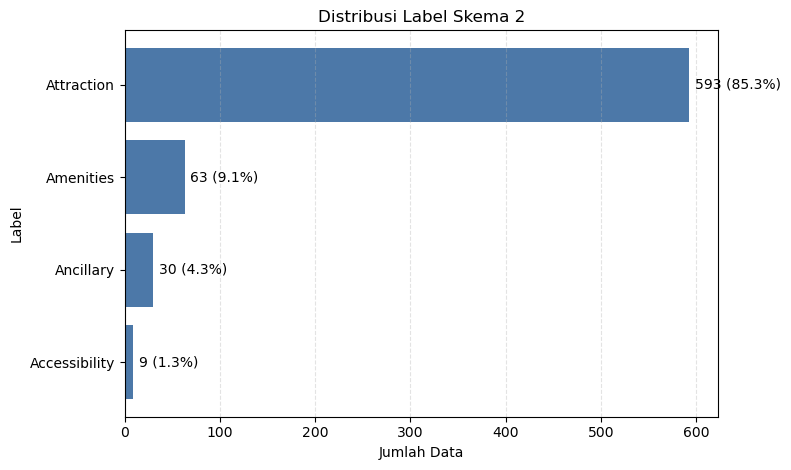

,count
label,
Attraction,593
Amenities,63
Ancillary,30
Accessibility,9


Visualisasi distribusi label tersimpan di: ouputmodel\label_distribution.png


In [4]:
label_counts = df['label'].value_counts().sort_values()
total_data = int(label_counts.sum())

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.barh(label_counts.index, label_counts.values, color='#4C78A8')
ax.set_title('Distribusi Label Skema 2')
ax.set_xlabel('Jumlah Data')
ax.set_ylabel('Label')
ax.grid(axis='x', linestyle='--', alpha=0.35)

max_count = max(label_counts.values) if len(label_counts) else 0
for bar, value in zip(bars, label_counts.values):
    percent = 100 * value / total_data
    ax.text(value + max_count * 0.01, bar.get_y() + bar.get_height() / 2, f'{value} ({percent:.1f}%)', va='center')

fig.tight_layout()
fig.savefig(LABEL_DIST_PATH, dpi=200, bbox_inches='tight')
plt.show()

display(label_counts.sort_values(ascending=False).to_frame('count'))
print(f'Visualisasi distribusi label tersimpan di: {LABEL_DIST_PATH}')


## Split data 80:20 stratified

In [5]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['label_id'],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

split_counts = pd.concat(
    [
        train_df['label'].value_counts().rename('train'),
        val_df['label'].value_counts().rename('validation'),
    ],
    axis=1,
).fillna(0).astype(int).loc[label_names]

print(f'Train: {len(train_df)} data ({len(train_df) / len(df):.1%})')
print(f'Validation: {len(val_df)} data ({len(val_df) / len(df):.1%})')
display(split_counts)


Train: 556 data (80.0%)
Validation: 139 data (20.0%)


,train,validation
label,,
Accessibility,7,2
Amenities,51,12
Ancillary,24,6
Attraction,474,119


## Load model encoder

In [6]:
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE)

tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
text_model = AutoModel.from_pretrained(TEXT_MODEL_NAME).to(DEVICE)

clip_model.eval()
text_model.eval()

for param in clip_model.parameters():
    param.requires_grad = False

for param in text_model.parameters():
    param.requires_grad = False

print(f'CLIP embedding dim: {clip_model.config.projection_dim}')
print(f'Text embedding dim: {text_model.config.hidden_size}')


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: cardiffnlp/twitter-xlm-roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


CLIP embedding dim: 512
Text embedding dim: 768


## Ekstraksi fitur gambar dan teks

Augmentasi ringan diterapkan hanya untuk gambar training saat ekstraksi fitur. Validation dibuat deterministik tanpa augmentasi.

In [7]:
RESAMPLE = Image.Resampling.BICUBIC if hasattr(Image, 'Resampling') else Image.BICUBIC


def light_image_augment(image):
    if random.random() < 0.35:
        image = ImageOps.mirror(image)

    if random.random() < 0.45:
        width, height = image.size
        scale = random.uniform(0.92, 1.0)
        crop_width = max(1, int(width * scale))
        crop_height = max(1, int(height * scale))
        left = random.randint(0, max(0, width - crop_width))
        top = random.randint(0, max(0, height - crop_height))
        image = image.crop((left, top, left + crop_width, top + crop_height)).resize((width, height), RESAMPLE)

    if random.random() < 0.50:
        image = ImageEnhance.Brightness(image).enhance(random.uniform(0.92, 1.08))
    if random.random() < 0.50:
        image = ImageEnhance.Contrast(image).enhance(random.uniform(0.92, 1.08))
    if random.random() < 0.35:
        image = ImageEnhance.Color(image).enhance(random.uniform(0.92, 1.08))

    return image


def load_image(path, augment=False):
    image = ImageOps.exif_transpose(Image.open(path)).convert('RGB')
    if augment:
        image = light_image_augment(image)
    return image


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def clip_image_output_to_tensor(output):
    if torch.is_tensor(output):
        return output

    if hasattr(output, 'image_embeds') and output.image_embeds is not None:
        return output.image_embeds

    if hasattr(output, 'pooler_output') and output.pooler_output is not None:
        pooled_output = output.pooler_output
        if hasattr(clip_model, 'visual_projection') and pooled_output.shape[-1] == clip_model.visual_projection.in_features:
            return clip_model.visual_projection(pooled_output)
        return pooled_output

    if isinstance(output, (tuple, list)):
        for item in output:
            if torch.is_tensor(item):
                return item

    raise TypeError(f'Output CLIP tidak bisa dikonversi ke tensor: {type(output)}')


def encode_clip_images(pixel_values):
    if hasattr(clip_model, 'vision_model') and hasattr(clip_model, 'visual_projection'):
        vision_outputs = clip_model.vision_model(pixel_values=pixel_values, return_dict=True)
        return clip_model.visual_projection(vision_outputs.pooler_output)

    return clip_image_output_to_tensor(clip_model.get_image_features(pixel_values=pixel_values))


@torch.no_grad()
def extract_image_features(image_paths, augment=False, batch_size=BATCH_SIZE, desc='image features'):
    features = []
    clip_model.eval()

    for start in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[start:start + batch_size]
        images = [load_image(path, augment=augment) for path in batch_paths]
        inputs = clip_processor(images=images, return_tensors='pt')
        pixel_values = inputs['pixel_values'].to(DEVICE)
        batch_features = encode_clip_images(pixel_values)
        batch_features = F.normalize(batch_features, dim=-1)
        features.append(batch_features.cpu())

    return torch.cat(features, dim=0)


@torch.no_grad()
def extract_text_features(captions, batch_size=BATCH_SIZE, max_length=TEXT_MAX_LENGTH, desc='text features'):
    features = []
    text_model.eval()
    captions = [caption if str(caption).strip() else ' ' for caption in captions]

    for start in tqdm(range(0, len(captions), batch_size), desc=desc):
        batch_text = captions[start:start + batch_size]
        inputs = tokenizer(
            batch_text,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt',
        ).to(DEVICE)
        outputs = text_model(**inputs)
        batch_features = mean_pooling(outputs.last_hidden_state, inputs['attention_mask'])
        batch_features = F.normalize(batch_features, dim=-1)
        features.append(batch_features.cpu())

    return torch.cat(features, dim=0)


In [8]:
train_image_features = extract_image_features(train_df['image_path'].tolist(), augment=True, desc='train image features')
val_image_features = extract_image_features(val_df['image_path'].tolist(), augment=False, desc='validation image features')

train_text_features = extract_text_features(train_df['caption'].tolist(), desc='train text features')
val_text_features = extract_text_features(val_df['caption'].tolist(), desc='validation text features')

y_train = torch.tensor(train_df['label_id'].values, dtype=torch.long)
y_val = torch.tensor(val_df['label_id'].values, dtype=torch.long)

print('train_image_features:', tuple(train_image_features.shape))
print('train_text_features:', tuple(train_text_features.shape))
print('val_image_features:', tuple(val_image_features.shape))
print('val_text_features:', tuple(val_text_features.shape))


train image features:   0%|          | 0/35 [00:00<?, ?it/s]

validation image features:   0%|          | 0/9 [00:00<?, ?it/s]

train text features:   0%|          | 0/35 [00:00<?, ?it/s]

validation text features:   0%|          | 0/9 [00:00<?, ?it/s]

train_image_features: (556, 512)
train_text_features: (556, 768)
val_image_features: (139, 512)
val_text_features: (139, 768)


## Dataset fitur, focal loss, dan model intermediate fusion

In [9]:
class FusionFeatureDataset(Dataset):
    def __init__(self, image_features, text_features, labels):
        self.image_features = image_features.float()
        self.text_features = text_features.float()
        self.labels = labels.long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.image_features[idx], self.text_features[idx], self.labels[idx]


class IntermediateFusionClassifier(nn.Module):
    def __init__(self, image_dim=512, text_dim=768, project_dim=256, num_classes=4, dropout=0.30):
        super().__init__()
        self.image_projection = nn.Sequential(
            nn.Linear(image_dim, project_dim),
            nn.LayerNorm(project_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.text_projection = nn.Sequential(
            nn.Linear(text_dim, project_dim),
            nn.LayerNorm(project_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.mlp = nn.Sequential(
            nn.Linear(project_dim * 2, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, image_features, text_features):
        image_projected = self.image_projection(image_features)
        text_projected = self.text_projection(text_features)
        fused = torch.cat([image_projected, text_projected], dim=1)
        return self.mlp(fused)


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        if alpha is not None:
            self.register_buffer('alpha', alpha.float())
        else:
            self.alpha = None

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        if self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


train_dataset = FusionFeatureDataset(train_image_features, train_text_features, y_train)
val_dataset = FusionFeatureDataset(val_image_features, val_text_features, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=DEVICE.type == 'cuda')
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=DEVICE.type == 'cuda')

num_classes = len(label_names)
class_counts = np.bincount(train_df['label_id'].values, minlength=num_classes)
alpha = class_counts.sum() / np.maximum(class_counts, 1)
alpha = alpha / alpha.mean()
alpha = torch.tensor(alpha, dtype=torch.float32, device=DEVICE)

model = IntermediateFusionClassifier(
    image_dim=train_image_features.shape[1],
    text_dim=train_text_features.shape[1],
    project_dim=PROJECT_DIM,
    num_classes=num_classes,
).to(DEVICE)

criterion = FocalLoss(alpha=alpha, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)

print('Class counts train:', dict(zip(label_names, class_counts.tolist())))
print('Focal alpha:', dict(zip(label_names, alpha.detach().cpu().numpy().round(3).tolist())))


Class counts train: {'Accessibility': 7, 'Amenities': 51, 'Ancillary': 24, 'Attraction': 474}
Focal alpha: {'Accessibility': 2.7709999084472656, 'Amenities': 0.3799999952316284, 'Ancillary': 0.8080000281333923, 'Attraction': 0.04100000113248825}


## Training

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_targets = []
    all_preds = []

    for image_features, text_features, labels in loader:
        image_features = image_features.to(DEVICE)
        text_features = text_features.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            logits = model(image_features, text_features)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        total_loss += loss.item() * labels.size(0)
        all_targets.extend(labels.detach().cpu().tolist())
        all_preds.extend(torch.argmax(logits.detach(), dim=1).cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_targets, all_preds)
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return {'loss': avg_loss, 'accuracy': accuracy, 'macro_f1': macro_f1}


history = []
best_val_loss = float('inf')
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_metrics = run_epoch(model, val_loader, criterion)
    scheduler.step(val_metrics['loss'])

    current_lr = optimizer.param_groups[0]['lr']
    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'train_macro_f1': train_metrics['macro_f1'],
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_macro_f1': val_metrics['macro_f1'],
        'learning_rate': current_lr,
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {train_metrics['loss']:.4f} acc {train_metrics['accuracy']:.4f} f1 {train_metrics['macro_f1']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} acc {val_metrics['accuracy']:.4f} f1 {val_metrics['macro_f1']:.4f} | "
        f"lr {current_lr:.2e}"
    )

    improved = val_metrics['loss'] < best_val_loss - 1e-4
    if improved:
        best_val_loss = val_metrics['loss']
        epochs_without_improvement = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)

        metadata = {
            'clip_model_name': CLIP_MODEL_NAME,
            'text_model_name': TEXT_MODEL_NAME,
            'image_dim': int(train_image_features.shape[1]),
            'text_dim': int(train_text_features.shape[1]),
            'project_dim': PROJECT_DIM,
            'num_classes': num_classes,
            'label_to_id': label_to_id,
            'id_to_label': id_to_label,
            'best_epoch': epoch,
            'best_val_loss': best_val_loss,
            'batch_size': BATCH_SIZE,
            'epochs': EPOCHS,
            'optimizer': 'AdamW',
            'scheduler': 'ReduceLROnPlateau',
            'early_stopping_patience': EARLY_STOPPING_PATIENCE,
            'class_counts_train': {label: int(count) for label, count in zip(label_names, class_counts.tolist())},
        }
        METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
        print(f'  -> checkpoint terbaik disimpan: {BEST_MODEL_PATH}')
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f'Early stopping aktif setelah {EARLY_STOPPING_PATIENCE} epoch tanpa improvement.')
        break

history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_CSV_PATH, index=False)
display(history_df)
print(f'History training tersimpan di: {HISTORY_CSV_PATH}')

Epoch 01/24 | train loss 0.1314 acc 0.5396 f1 0.2471 | val loss 0.1280 acc 0.6906 f1 0.4757 | lr 2.00e-04
  -> checkpoint terbaik disimpan: ouputmodel\best_intermediate_fusion.pt
Epoch 02/24 | train loss 0.1099 acc 0.5036 f1 0.2864 | val loss 0.1252 acc 0.7482 f1 0.4646 | lr 2.00e-04
  -> checkpoint terbaik disimpan: ouputmodel\best_intermediate_fusion.pt
Epoch 03/24 | train loss 0.1082 acc 0.5971 f1 0.3540 | val loss 0.0996 acc 0.8921 f1 0.5550 | lr 2.00e-04
  -> checkpoint terbaik disimpan: ouputmodel\best_intermediate_fusion.pt
Epoch 04/24 | train loss 0.0662 acc 0.7302 f1 0.4365 | val loss 0.0900 acc 0.7914 f1 0.5280 | lr 2.00e-04
  -> checkpoint terbaik disimpan: ouputmodel\best_intermediate_fusion.pt
Epoch 05/24 | train loss 0.0328 acc 0.7698 f1 0.6419 | val loss 0.1129 acc 0.8777 f1 0.5905 | lr 2.00e-04
Epoch 06/24 | train loss 0.0319 acc 0.8219 f1 0.6167 | val loss 0.0850 acc 0.8849 f1 0.6054 | lr 2.00e-04
  -> checkpoint terbaik disimpan: ouputmodel\best_intermediate_fusion.pt

,epoch,train_loss,train_accuracy,train_macro_f1,val_loss,val_accuracy,val_macro_f1,learning_rate
0,1,0.131372,0.539568,0.247106,0.128022,0.690647,0.475705,0.0002
1,2,0.109859,0.503597,0.286429,0.125199,0.748201,0.464601,0.0002
2,3,0.108213,0.597122,0.353981,0.099636,0.892086,0.554964,0.0002
3,4,0.066190,0.730216,0.436545,0.090025,0.791367,0.527958,0.0002
4,5,0.032798,0.769784,0.641934,0.112898,0.877698,0.590462,0.0002
5,6,0.031891,0.821942,0.616656,0.084995,0.884892,0.605355,0.0002
6,7,0.021000,0.866906,0.757916,0.084435,0.892086,0.595722,0.0002
7,8,0.011121,0.879496,0.761794,0.106877,0.913669,0.619432,0.0002
8,9,0.007945,0.890288,0.847680,0.105565,0.892086,0.595722,0.0002
9,10,0.007345,0.911871,0.831400,0.098345,0.892086,0.595722,0.0001


History training tersimpan di: ouputmodel\training_history.csv


## Kurva training

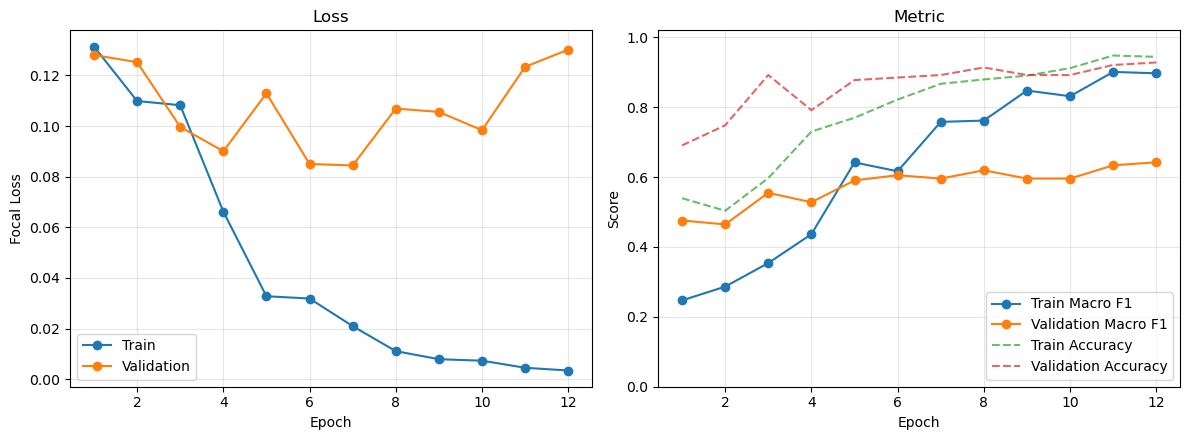

Kurva training tersimpan di: ouputmodel\training_curves.png


In [11]:
history_df = pd.read_csv(HISTORY_CSV_PATH) if HISTORY_CSV_PATH.exists() else pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Validation')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_macro_f1'], marker='o', label='Train Macro F1')
axes[1].plot(history_df['epoch'], history_df['val_macro_f1'], marker='o', label='Validation Macro F1')
axes[1].plot(history_df['epoch'], history_df['train_accuracy'], linestyle='--', alpha=0.7, label='Train Accuracy')
axes[1].plot(history_df['epoch'], history_df['val_accuracy'], linestyle='--', alpha=0.7, label='Validation Accuracy')
axes[1].set_title('Metric')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.3)
axes[1].legend()

fig.tight_layout()
fig.savefig(TRAINING_CURVE_PATH, dpi=200, bbox_inches='tight')
plt.show()

print(f'Kurva training tersimpan di: {TRAINING_CURVE_PATH}')


## Evaluasi checkpoint terbaik dan confusion matrix

Best checkpoint validation metrics: {'loss': 0.08443489050988456, 'accuracy': 0.8920863309352518, 'macro_f1': 0.595721653365457}
               precision    recall  f1-score   support

Accessibility       0.00      0.00      0.00         2
    Amenities       0.59      0.83      0.69        12
    Ancillary       0.60      1.00      0.75         6
   Attraction       0.98      0.91      0.94       119

     accuracy                           0.89       139
    macro avg       0.54      0.69      0.60       139
 weighted avg       0.92      0.89      0.90       139



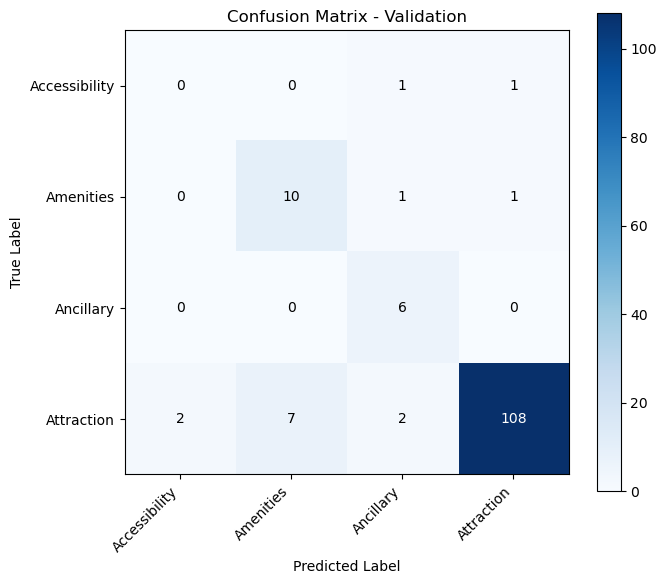

Confusion matrix tersimpan di: ouputmodel\confusion_matrix.png
Prediksi validation tersimpan di: ouputmodel\validation_predictions.csv


In [12]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
best_val_metrics = run_epoch(model, val_loader, criterion)
print('Best checkpoint validation metrics:', best_val_metrics)


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_targets = []
    all_preds = []
    all_probs = []

    for image_features, text_features, labels in loader:
        image_features = image_features.to(DEVICE)
        text_features = text_features.to(DEVICE)
        logits = model(image_features, text_features)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_targets.extend(labels.cpu().tolist())
        all_preds.extend(preds.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

    return np.array(all_targets), np.array(all_preds), np.array(all_probs)


y_true, y_pred, y_prob = predict_loader(model, val_loader)

print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(image, ax=ax)

ax.set_title('Confusion Matrix - Validation')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_xticks(np.arange(num_classes))
ax.set_yticks(np.arange(num_classes))
ax.set_xticklabels(label_names, rotation=45, ha='right')
ax.set_yticklabels(label_names)

threshold = cm.max() / 2 if cm.size else 0
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > threshold else 'black')

fig.tight_layout()
fig.savefig(CONFUSION_MATRIX_PATH, dpi=200, bbox_inches='tight')
plt.show()

prediction_df = val_df[['file', 'caption', 'label']].copy()
prediction_df['prediction'] = [label_names[idx] for idx in y_pred]
prediction_df['correct'] = prediction_df['label'].eq(prediction_df['prediction'])
prediction_df.to_csv(PREDICTION_CSV_PATH, index=False, encoding='utf-8')

print(f'Confusion matrix tersimpan di: {CONFUSION_MATRIX_PATH}')
print(f'Prediksi validation tersimpan di: {PREDICTION_CSV_PATH}')
